# Calculate the Depths of Offshore Wind Turbines in the North Sea — GeoPandas + rasterio Reproduction

This notebook reproduces the workflow of `_1_determine_offshore_turbine_depths.ipynb` using the **GeoPandas + rasterio + shapely** stack. Compared to the raw-GDAL reproduction, this version is much closer in style to the GeoKit version: dataframes for vectors and clean array/affine pairs for rasters.

Steps:

1. Data Preparation and Script Setup
2. Load and display the North Sea polygon (GeoPandas)
3. Filter and merge the bathymetry tiles, then mask to the North Sea (`rasterio.merge`, `rasterio.mask`)
4. Load and display the offshore wind turbine locations (GeoPandas)
5. Sample water depth at the turbine locations (`rasterio.DatasetReader.sample`)

## 1. Data Preparation and Script Setup

### 1.1 Imports

We rely on `geopandas` for vector I/O and joins, `rasterio` (plus its `merge`, `mask`, `plot` submodules) for raster operations, and `shapely` for any direct geometry manipulation. `ZenodoDataDownloader` is reused only as a download helper.

In [ ]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.mask import mask as rio_mask
from rasterio.plot import show as rio_show

from geokit.core.get_test_data import ZenodoDataDownloader  # download helper only

current_working_directory = pathlib.Path.cwd()

### 1.2 Download the input data

Identical to the GeoKit notebook: IHO sea basins, 2050 offshore wind turbine locations, and pre-tiled GEBCO bathymetry.

In [ ]:
iho_download = (
    "https://geo.vliz.be/geoserver/wfs?request=getfeature&service=wfs&version=1.0.0&typename=MarineRegions:iho&outputformat=SHAPE-ZIP",
    "iho.zip",
    "iho",
    {},
)
turbine_location_download = (
    "https://zenodo.org/record/10259046/files/turbine_locations shapefile.zip?download=1",
    "turbine_locations_shapefile.zip",
    "turbine_locations_shapefile",
    {},
)
gebco_tiles_download = (
    "https://zenodo.org/record/17047388/files/gebco_tiles.zip?download=1",
    "gebco_tiles.zip",
    "gebco_tiles",
    {},
)

data_downloader = ZenodoDataDownloader()
(
    path_to_sea_basins_folder,
    path_to_offshore_wind_points_folder,
    path_to_bathymetry_rasters_folder,
) = data_downloader.download_and_extract_parallel(
    download_list=[iho_download, turbine_location_download, gebco_tiles_download]
)

path_to_sea_basins_shape_file = path_to_sea_basins_folder.joinpath("iho.shp")

## 2. Load, Extract and Display the North Sea Polygon

GeoPandas reads shapefiles directly into a `GeoDataFrame`. We can either pass a `where` clause through to OGR (mirroring GeoKit) or filter in Python. Both forms are shown.

In [3]:
# Option A: push the filter down to OGR (analogous to geokit.vector.extractFeatures(where=...))
north_sea_gdf = gpd.read_file(path_to_sea_basins_shape_file, where="NAME = 'North Sea'")

# Option B: filter in Python after reading
# all_basins = gpd.read_file(path_to_sea_basins_shape_file)
# north_sea_gdf = all_basins[all_basins["NAME"] == "North Sea"].copy()

if north_sea_gdf.crs is None:
    north_sea_gdf = north_sea_gdf.set_crs("EPSG:4326")
else:
    north_sea_gdf = north_sea_gdf.to_crs("EPSG:4326")

north_sea_geom = north_sea_gdf.geometry.iloc[0]
north_sea_bounds = north_sea_gdf.total_bounds  # [minx, miny, maxx, maxy]
north_sea_gdf.head()

,name,id,longitude,latitude,min_x,min_y,max_x,max_y,area,mrgid,geometry
0,North Sea,4,2.73786,56.423995,-4.445371,50.995365,12.005942,61.017023,524493.0,2350,"POLYGON ((5.20322 60.83209, 5.20194 60.83269, ..."


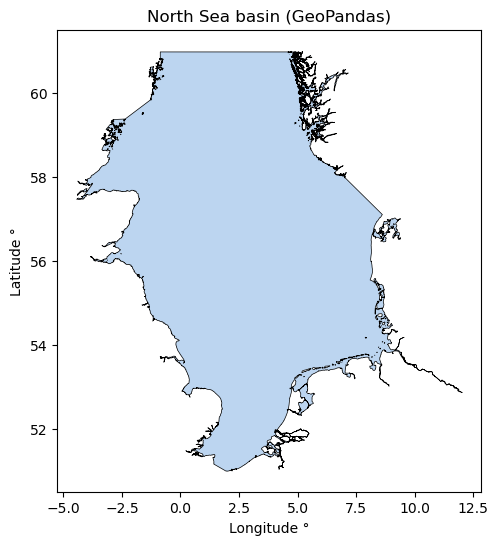

In [4]:
fig1, ax1 = plt.subplots(figsize=(6, 6))
north_sea_gdf.plot(ax=ax1, facecolor="#bcd5f0", edgecolor="black", linewidth=0.5)
ax1.set_xlabel("Longitude °")
ax1.set_ylabel("Latitude °")
ax1.set_title("North Sea basin (GeoPandas)")
plt.show()

## 3. Match Bathymetry Raster Data to the North Sea

### 3.1 Filter raster tiles overlapping the North Sea

Using rasterio we open each tile, read its `bounds`, and keep the ones whose bounding box intersects the North Sea bounding box. This is the rasterio equivalent of `Extent.filterSources`.

In [5]:
def bounds_intersect(a, b):
    # both as (minx, miny, maxx, maxy)
    return not (a[2] < b[0] or a[0] > b[2] or a[3] < b[1] or a[1] > b[3])


ns_bounds = tuple(north_sea_bounds)  # (minx, miny, maxx, maxy)
all_tile_paths = sorted(pathlib.Path(path_to_bathymetry_rasters_folder).glob("*.tif"))
bathymetry_tile_paths = []
for tile_path in all_tile_paths:
    with rasterio.open(tile_path) as src:
        tile_bounds = (src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top)
    if bounds_intersect(tile_bounds, ns_bounds):
        bathymetry_tile_paths.append(tile_path)

bathymetry_tile_paths

[PosixPath('geokit/data/gebco_tiles/gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_08.tif'),
 PosixPath('geokit/data/gebco_tiles/gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_09.tif'),
 PosixPath('geokit/data/gebco_tiles/gebco_2020_n90.0_s-90.0_w-180.0_e180.0_04_08.tif'),
 PosixPath('geokit/data/gebco_tiles/gebco_2020_n90.0_s-90.0_w-180.0_e180.0_04_09.tif')]

### 3.2 Combine the relevant tiles into a single raster

`rasterio.merge.merge` is the direct equivalent of `combineSimilarRasters`. It returns the merged array and its affine transform; we then write the result to a GeoTIFF for downstream use.

In [6]:
open_tiles = [rasterio.open(p) for p in bathymetry_tile_paths]
merged_array, merged_transform = rio_merge(open_tiles)

ref_meta = open_tiles[0].meta.copy()
for ds in open_tiles:
    ds.close()

ref_meta.update(
    {
        "driver": "GTiff",
        "height": merged_array.shape[1],
        "width": merged_array.shape[2],
        "transform": merged_transform,
        "compress": "LZW",
        "tiled": True,
    }
)

merged_path = current_working_directory.joinpath("bathymetry_raster_NorthSea_rio.tif")
with rasterio.open(merged_path, "w", **ref_meta) as dst:
    dst.write(merged_array)

assert np.isclose(abs(merged_transform.a), abs(merged_transform.e)), (
    "Pixel width and height must be equal."
)
print(f"Merged raster: {merged_array.shape} (bands, rows, cols)")

Merged raster: (1, 5400, 10800) (bands, rows, cols)


### 3.3 Mask the merged raster to the North Sea polygon

`rasterio.mask.mask` clips a raster to the supplied geometries and (with `crop=True`) reduces the array to the geometries' bounding box — the rasterio equivalent of `RegionMask.warp`.

In [7]:
with rasterio.open(merged_path) as src:
    masked_array, masked_transform = rio_mask(
        dataset=src,
        shapes=[north_sea_geom.__geo_interface__],
        crop=True,
        nodata=-9999,
        filled=True,
    )
    masked_meta = src.meta.copy()

masked_meta.update(
    {
        "height": masked_array.shape[1],
        "width": masked_array.shape[2],
        "transform": masked_transform,
        "nodata": -9999,
    }
)

masked_path = current_working_directory.joinpath("bathymetry_NorthSea_masked_rio.tif")
with rasterio.open(masked_path, "w", **masked_meta) as dst:
    dst.write(masked_array)

# For plotting, swap the nodata sentinel for NaN
plot_array = masked_array[0].astype("float64")
plot_array = np.where(plot_array == -9999, np.nan, plot_array)
print("Masked raster shape:", plot_array.shape)

Masked raster shape: (2407, 3949)


### 3.4 Display the bathymetry inside the North Sea

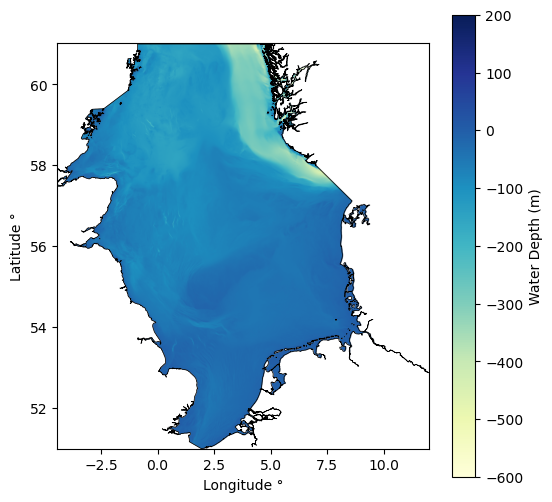

In [8]:
fig2, ax2 = plt.subplots(figsize=(6, 6))
with rasterio.open(masked_path) as src:
    rio_show(
        src,
        ax=ax2,
        cmap="YlGnBu",
        vmin=-600,
        vmax=200,
    )
north_sea_gdf.plot(ax=ax2, facecolor="none", edgecolor="black", linewidth=0.5)

# rio_show does not return a colorbar mappable, so we add one manually.
im = ax2.images[0]
fig2.colorbar(im, ax=ax2, label="Water Depth (m)")
ax2.set_xlabel("Longitude °")
ax2.set_ylabel("Latitude °")
plt.show()

## 4. Load and Display the Offshore Wind Turbine Locations

GeoPandas reads the points shapefile straight into a `GeoDataFrame`. We then plot it on top of the masked bathymetry.

### 4.1 Load the Offshore Wind Turbine Locations

In [9]:
turbines_gdf = gpd.read_file(path_to_offshore_wind_points_folder)
if turbines_gdf.crs is None:
    turbines_gdf = turbines_gdf.set_crs("EPSG:4326")
else:
    turbines_gdf = turbines_gdf.to_crs("EPSG:4326")

print(f"Loaded {len(turbines_gdf)} turbine locations.")



Loaded 19605 turbine locations.


### 4.2 Display the Offshore Wind Turbine Locations

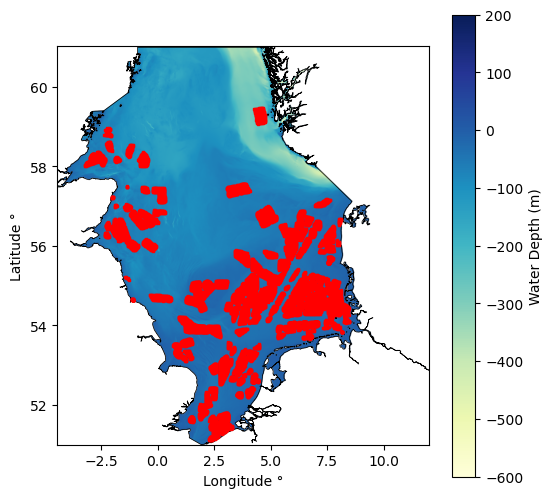

In [10]:
fig3, ax3 = plt.subplots(figsize=(6, 6))
with rasterio.open(masked_path) as src:
    rio_show(src, ax=ax3, cmap="YlGnBu", vmin=-600, vmax=200)
north_sea_gdf.plot(ax=ax3, facecolor="none", edgecolor="black", linewidth=0.5)
turbines_gdf.plot(ax=ax3, color="red", markersize=2, marker=",")
fig3.colorbar(ax3.images[0], ax=ax3, label="Water Depth (m)")
ax3.set_xlabel("Longitude °")
ax3.set_ylabel("Latitude °")
plt.show()

## 5. Extract Water Depths at Turbine Locations

`rasterio.DatasetReader.sample` takes an iterable of `(x, y)` coordinates and yields the raster values at the nearest pixel — the same default behaviour as GeoKit's `interpolateValues(..., mode="near")`.

In [11]:
coords = list(zip(turbines_gdf.geometry.x, turbines_gdf.geometry.y))
with rasterio.open(masked_path) as src:
    nodata = src.nodata
    sampled = np.array([v[0] for v in src.sample(coords)], dtype="float64")

if nodata is not None:
    sampled = np.where(sampled == nodata, np.nan, sampled)

turbines_gdf["depth"] = sampled

print("depth statistics (m):")
print(f"  min = {np.nanmin(sampled):.1f}")
print(f"  max = {np.nanmax(sampled):.1f}")
print(f"  mean= {np.nanmean(sampled):.1f}")
turbines_gdf.head()

depth statistics (m):
  min = -283.0
  max = -1.0
  mean= -43.0


,Latitude,Longitude,Source,Year,Capacity,geometry,depth
0,51.590921,2.890734,DOWT,NaN,NaN,POINT (2.89073 51.59092),-32.0
1,51.595143,2.899807,DOWT,NaN,NaN,POINT (2.89981 51.59514),-32.0
2,51.586339,2.897291,DOWT,NaN,NaN,POINT (2.89729 51.58634),-30.0
3,51.581578,2.904927,DOWT,NaN,NaN,POINT (2.90493 51.58158),-27.0
4,51.568373,2.929721,DOWT,NaN,NaN,POINT (2.92972 51.56837),-25.0


The resulting `turbines_gdf` mirrors the `offshore_wind_points` dataframe of the GeoKit notebook: it carries the original turbine geometries plus the new `depth` column extracted from the bathymetry raster, ready for downstream analyses like cost modelling or foundation-type screening.